In [24]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

from networks import PINN

PDE residual

In [3]:
 def pde_residual(model, t, z, k, S_max):
        t.requires_grad_(True)
        z.requires_grad_(True)

        S, v_m = model(t, z)

        # dS/dt
        dS_dt = torch.autograd.grad(
            S, t,
            grad_outputs=torch.ones_like(S),
            create_graph=True
        )[0]

        # dS/dz
        dS_dz = torch.autograd.grad(
            S, z,
            grad_outputs=torch.ones_like(S),
            create_graph=True
        )[0]

        # PDE
        residual = dS_dt + v_m * dS_dz - k * (S_max - S)

        return residual

Loss-функция PINN

Полная loss: L = Lpde+Lbc+Lic

In [4]:
def loss_function(model, t_f, z_f,   # collocation points
                  t_bc, z_bc, S_bc, # boundary
                  t_ic, z_ic, S_ic, # initial
                  k, S_max):

    # PDE loss
    res = pde_residual(model, t_f, z_f, k, S_max)
    loss_pde = torch.mean(res**2)

    # Boundary condition (z=0)
    S_pred_bc, _ = model(t_bc, z_bc)
    loss_bc = torch.mean((S_pred_bc - S_bc)**2)

    # Initial condition (t=0)
    S_pred_ic, _ = model(t_ic, z_ic)
    loss_ic = torch.mean((S_pred_ic - S_ic)**2)

    return loss_pde + loss_bc + loss_ic

## Процесс обучения:

In [9]:
N_bc = 1000

t_bc = torch.rand(N_bc, 1) * 1800  # время
z_bc = torch.zeros_like(t_bc)      # z = 0

# пример: константный вход
S_in_value = 50.0
S_bc = torch.ones_like(t_bc) * S_in_value

In [10]:
N_ic = 1000

t_ic = torch.zeros(N_ic, 1)           # t = 0
z_ic = torch.rand(N_ic, 1) * 10       # вдоль мельницы

# пример: равномерное начальное состояние
S0_value = 10.0
S_ic = torch.ones_like(z_ic) * S0_value

In [11]:
N_f = 10000

t_f = torch.rand(N_f, 1) * 1800
z_f = torch.rand(N_f, 1) * 10

In [12]:
t_bc = t_bc / 1800
z_bc = z_bc / 10

t_ic = t_ic / 1800
z_ic = z_ic / 10

t_f = t_f / 1800
z_f = z_f / 10

In [13]:
model = PINN(epochs=10000, lr=0.001, n_units=100)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# параметры
k = torch.tensor(0.1)
S_max = torch.tensor(500.0)

for epoch in range(model.epochs):

    optimizer.zero_grad()

    loss = loss_function(
        model,
        t_f, z_f,
        t_bc, z_bc, S_bc,
        t_ic, z_ic, S_ic,
        k, S_max
    )

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 5103.919921875
Epoch 500, Loss: 215.95750427246094
Epoch 1000, Loss: 40.086544036865234
Epoch 1500, Loss: 25.359216690063477
Epoch 2000, Loss: 23.014217376708984
Epoch 2500, Loss: 17.968772888183594
Epoch 3000, Loss: 13.772165298461914
Epoch 3500, Loss: 6.70082950592041
Epoch 4000, Loss: 3.165175437927246
Epoch 4500, Loss: 2.107971668243408
Epoch 5000, Loss: 1.5477244853973389
Epoch 5500, Loss: 1.4371798038482666
Epoch 6000, Loss: 0.9183874130249023
Epoch 6500, Loss: 0.7401017546653748
Epoch 7000, Loss: 0.5883535742759705
Epoch 7500, Loss: 3.9212896823883057
Epoch 8000, Loss: 0.37973088026046753
Epoch 8500, Loss: 10.990739822387695
Epoch 9000, Loss: 3.9898016452789307
Epoch 9500, Loss: 2.0131144523620605


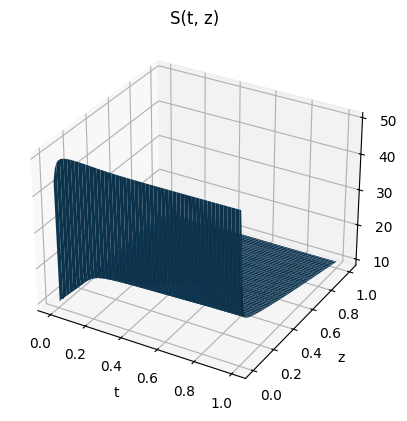

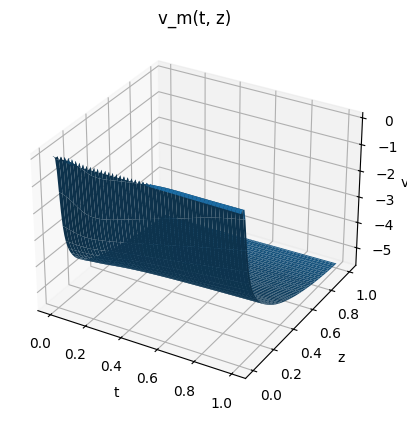

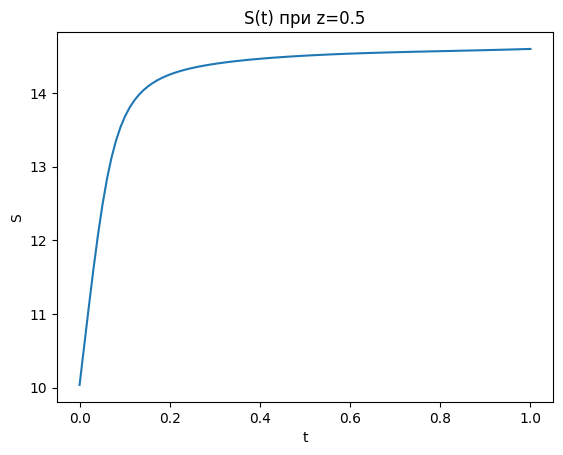

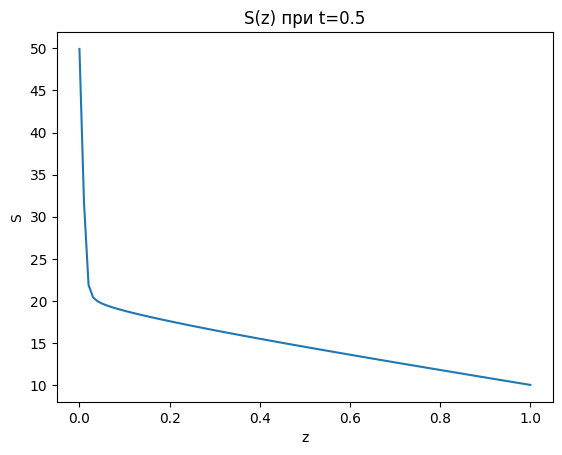

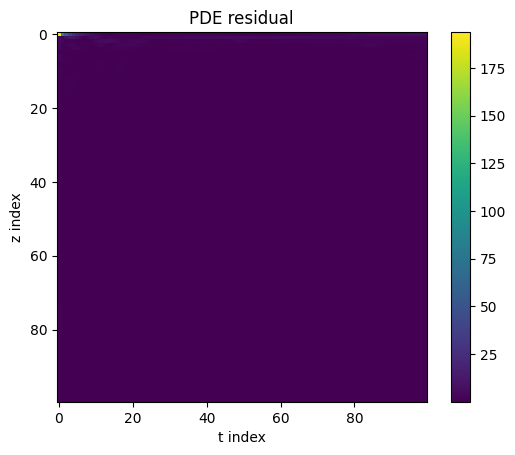

In [15]:
# =========================
# 1. Создание сетки
# =========================
t = np.linspace(0, 1, 100)
z = np.linspace(0, 1, 100)

T, Z = np.meshgrid(t, z)

t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).reshape(-1, 1)
z_tensor = torch.tensor(Z.flatten(), dtype=torch.float32).reshape(-1, 1)

# =========================
# 2. Прогон через модель
# =========================
model.eval()
with torch.no_grad():
    S_pred, v_pred = model(t_tensor, z_tensor)

S = S_pred.reshape(100, 100).cpu().numpy()
V = v_pred.reshape(100, 100).cpu().numpy()

# =========================
# 3. График 1: S(t, z)
# =========================
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(T, Z, S)
ax.set_title("S(t, z)")
ax.set_xlabel("t")
ax.set_ylabel("z")
ax.set_zlabel("S")
plt.show()

# =========================
# 4. График 2: v_m(t, z)
# =========================
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(T, Z, V)
ax.set_title("v_m(t, z)")
ax.set_xlabel("t")
ax.set_ylabel("z")
ax.set_zlabel("v_m")
plt.show()

# =========================
# 5. График 3: S(t) при z=0.5
# =========================
z_idx = 50
plt.figure()
plt.plot(t, S[z_idx, :])
plt.title("S(t) при z=0.5")
plt.xlabel("t")
plt.ylabel("S")
plt.show()

# =========================
# 6. График 4: S(z) при t=0.5
# =========================
t_idx = 50
plt.figure()
plt.plot(z, S[:, t_idx])
plt.title("S(z) при t=0.5")
plt.xlabel("z")
plt.ylabel("S")
plt.show()

# =========================
# 7. График 5: PDE residual
# =========================
t_tensor.requires_grad_(True)
z_tensor.requires_grad_(True)

S_pred, v_pred = model(t_tensor, z_tensor)

dS_dt = torch.autograd.grad(
    S_pred, t_tensor,
    grad_outputs=torch.ones_like(S_pred),
    create_graph=True
)[0]

dS_dz = torch.autograd.grad(
    S_pred, z_tensor,
    grad_outputs=torch.ones_like(S_pred),
    create_graph=True
)[0]

# параметры (замени на свои)
k = 0.1
S_max = 500

residual = dS_dt + v_pred * dS_dz - k * (S_max - S_pred)

residual = residual.reshape(100, 100).detach().cpu().numpy()

plt.figure()
plt.imshow(np.abs(residual))
plt.title("PDE residual")
plt.xlabel("t index")
plt.ylabel("z index")
plt.colorbar()
plt.show()

In [16]:
import numpy as np

def solve_fdm(v_const=0.7, k=0.1, S_max=500,
              L=1.0, T=1.0,
              Nz=100, Nt=100):

    dz = L / (Nz - 1)
    dt = T / (Nt - 1)

    z = np.linspace(0, L, Nz)
    t = np.linspace(0, T, Nt)

    S = np.zeros((Nz, Nt))

    # начальное условие
    S[:, 0] = 10.0

    for n in range(0, Nt - 1):
        for i in range(1, Nz):

            # upwind схема
            dS_dz = (S[i, n] - S[i-1, n]) / dz

            S[i, n+1] = S[i, n] + dt * (
                -v_const * dS_dz + k * (S_max - S[i, n])
            )

        # граничное условие (z=0)
        S[0, n+1] = 50.0

    return t, z, S

In [17]:
def get_pinn_solution(model, t, z):
    T, Z = np.meshgrid(t, z)

    t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).reshape(-1, 1)
    z_tensor = torch.tensor(Z.flatten(), dtype=torch.float32).reshape(-1, 1)

    model.eval()
    with torch.no_grad():
        S_pred, _ = model(t_tensor, z_tensor)

    S = S_pred.reshape(len(z), len(t)).cpu().numpy()

    return T, Z, S

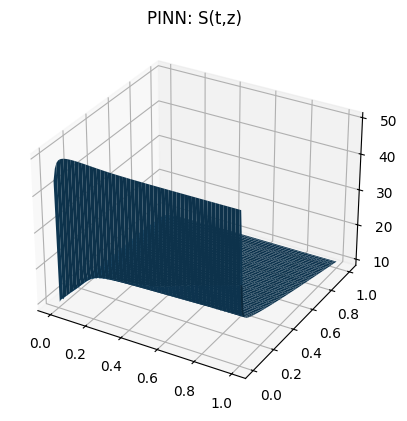

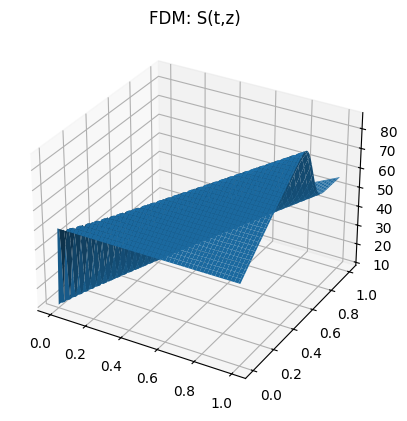

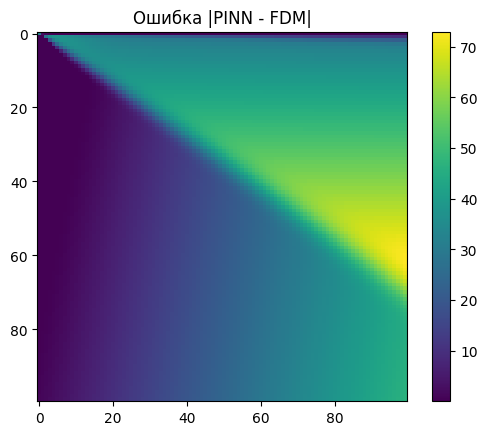

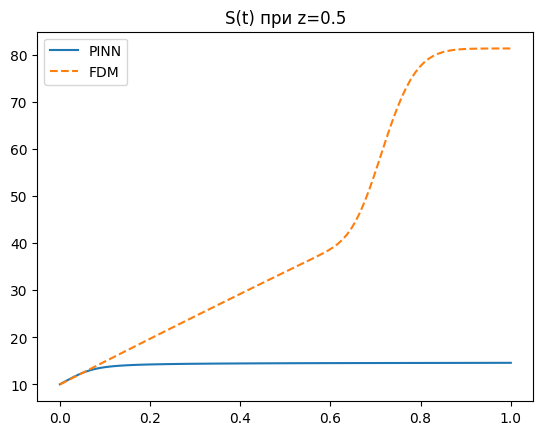

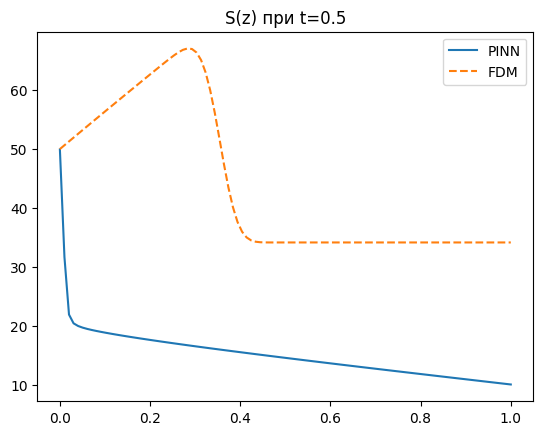

In [18]:
import matplotlib.pyplot as plt

# параметры
Nz = 100
Nt = 100

# FDM
t, z, S_fdm = solve_fdm(Nz=Nz, Nt=Nt)

# PINN
T, Z, S_pinn = get_pinn_solution(model, t, z)

# =========================
# 1. PINN поверхность
# =========================
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(T, Z, S_pinn)
ax.set_title("PINN: S(t,z)")
plt.show()

# =========================
# 2. FDM поверхность
# =========================
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(T, Z, S_fdm)
ax.set_title("FDM: S(t,z)")
plt.show()

# =========================
# 3. Разность
# =========================
error = np.abs(S_pinn - S_fdm)

plt.figure()
plt.imshow(error)
plt.title("Ошибка |PINN - FDM|")
plt.colorbar()
plt.show()

# =========================
# 4. Срез по времени
# =========================
z_idx = 50

plt.figure()
plt.plot(t, S_pinn[z_idx, :], label="PINN")
plt.plot(t, S_fdm[z_idx, :], linestyle='--', label="FDM")
plt.legend()
plt.title("S(t) при z=0.5")
plt.show()

# =========================
# 5. Срез по длине
# =========================
t_idx = 50

plt.figure()
plt.plot(z, S_pinn[:, t_idx], label="PINN")
plt.plot(z, S_fdm[:, t_idx], linestyle='--', label="FDM")
plt.legend()
plt.title("S(z) при t=0.5")
plt.show()

In [19]:
def analytical_solution(t, z, k=0.1, S_max=500, S_in=50):
    T, Z = np.meshgrid(t, z)

    S = S_max - (S_max - S_in) * np.exp(-k * T)

    return T, Z, S

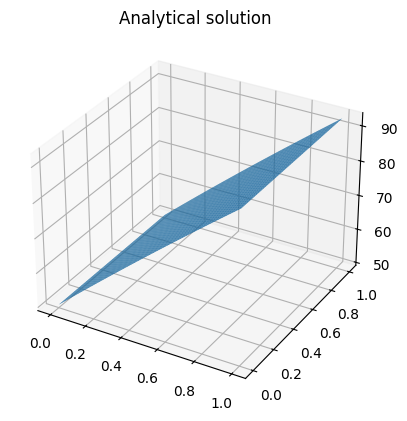

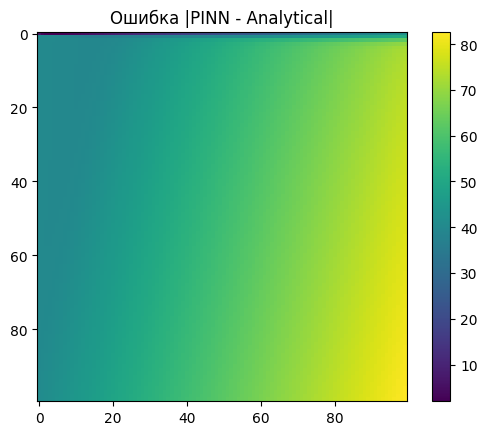

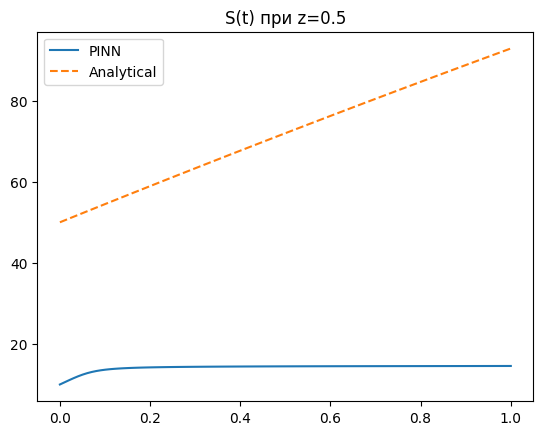

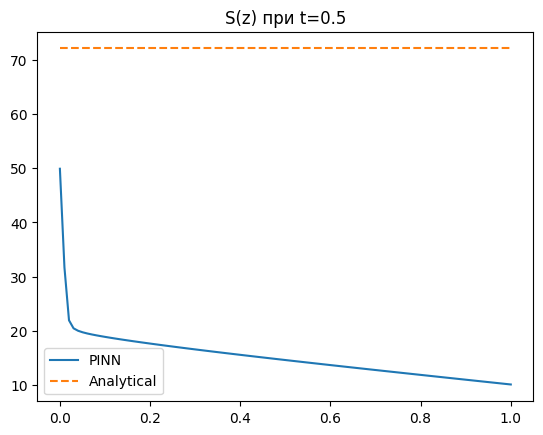

L2 error: 58.371576426965


In [20]:
# сетка
t = np.linspace(0, 1, 100)
z = np.linspace(0, 1, 100)

# PINN
T, Z, S_pinn = get_pinn_solution(model, t, z)

# аналитика
_, _, S_true = analytical_solution(t, z)

# =========================
# 1. Аналитическая поверхность
# =========================
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(T, Z, S_true)
ax.set_title("Analytical solution")
plt.show()

# =========================
# 2. Ошибка PINN
# =========================
error = np.abs(S_pinn - S_true)

plt.figure()
plt.imshow(error)
plt.title("Ошибка |PINN - Analytical|")
plt.colorbar()
plt.show()

# =========================
# 3. Срез по времени
# =========================
z_idx = 50

plt.figure()
plt.plot(t, S_pinn[z_idx, :], label="PINN")
plt.plot(t, S_true[z_idx, :], '--', label="Analytical")
plt.legend()
plt.title("S(t) при z=0.5")
plt.show()

# =========================
# 4. Срез по длине
# =========================
t_idx = 50

plt.figure()
plt.plot(z, S_pinn[:, t_idx], label="PINN")
plt.plot(z, S_true[:, t_idx], '--', label="Analytical")
plt.legend()
plt.title("S(z) при t=0.5")
plt.show()

# =========================
# 5. L2 ошибка (важно!)
# =========================
l2_error = np.sqrt(np.mean((S_pinn - S_true)**2))

print("L2 error:", l2_error)

In [ ]:
model_mdn = PINN_MDN(epochs=10000, lr=0.001, n_units=100)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# параметры
k = torch.tensor(0.1)
S_max = torch.tensor(500.0)

for epoch in range(10000):

    optimizer.zero_grad()

    loss = loss_function(
        model,
        t_f, z_f,
        t_bc, z_bc, S_bc,
        t_ic, z_ic, S_ic,
        k, S_max
    )

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")